# Исследование контекстного окна LLM, коррекции вероятностей слов и MECW

Этот ноутбук реализует методики из предоставленного исследовательского отчета в виде исполняемых Python-модулей. Логика намеренно детерминирована: анализ выполняется по логитам и скрытым состояниям, без стохастического семплера, temperature sampling, top-k или top-p.

Модули ноутбука:

1. Коррекция вероятностей слов по Pimentel & Meister для BoW-токенизаторов.
2. Доверительные прокси-метрики без семплера на основе логитов и траекторий hidden states.
3. Динамическое обнаружение Maximum Effective Context Window (MECW) по расширению доверительного интервала.
4. Поиск насыщения домена через n-граммную перплексию и метод локтя.
5. Визуализация и автоматическая интерпретация результатов.
6. Управление L2-состоянием агента по паттерну SATLUTION через локальный буфер `hypothesis.md` внутри папки `research`.

## Модуль 0: настройка среды выполнения

Отчет предполагает стандартный стек PyTorch и HuggingFace. Первая кодовая ячейка делает ноутбук запускаемым в свежей среде: устанавливает недостающие runtime-зависимости, затем импортирует детерминированные инструменты, используемые в следующих модулях.

In [1]:
# Автоматически устанавливаем только зависимости, нужные для этого ноутбука.
# Эта ячейка намеренно не устанавливает optional NLP-стеки вроде spaCy или NLTK;
# n-граммный пайплайн ниже использует легкий regex-токенизатор для переносимости.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "torch": "torch",
    "transformers": "transformers",
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
}

missing_packages = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing_packages:
    print(f"Устанавливаю недостающие пакеты: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Все необходимые пакеты уже установлены.")

Все необходимые пакеты уже установлены.


In [2]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple, Union
import json
import math
import os
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
# Направляем кэши внутрь research, чтобы выполнение ноутбука не писало в домашние директории.
def _bootstrap_research_cache_dir() -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "research":
        return cwd
    candidate = cwd / "research"
    if candidate.exists():
        return candidate.resolve()
    return cwd

_BOOTSTRAP_RESEARCH_DIR = _bootstrap_research_cache_dir()
os.environ.setdefault("HF_HOME", str(_BOOTSTRAP_RESEARCH_DIR / ".hf_cache"))
os.environ.setdefault("HF_HUB_CACHE", str(_BOOTSTRAP_RESEARCH_DIR / ".hf_cache" / "hub"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(_BOOTSTRAP_RESEARCH_DIR / ".hf_cache"))
os.environ.setdefault("MPLCONFIGDIR", str(_BOOTSTRAP_RESEARCH_DIR / ".matplotlib_cache"))
for _cache_dir in [os.environ["HF_HOME"], os.environ["HF_HUB_CACHE"], os.environ["MPLCONFIGDIR"]]:
    Path(_cache_dir).mkdir(parents=True, exist_ok=True)

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# Детерминированное выполнение. Стохастический семплер в ноутбуке не используется.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определяем папку research, не трогая файлы за ее пределами.
def resolve_research_dir() -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "research":
        return cwd
    candidate = cwd / "research"
    if candidate.exists():
        return candidate.resolve()
    raise RuntimeError("Запускайте этот ноутбук из корня репозитория или из папки research.")

RESEARCH_DIR = resolve_research_dir()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Папка исследования: {RESEARCH_DIR}")
print(f"Устройство: {DEVICE}")

def load_causal_lm(model_name: str = "gpt2", device: torch.device = DEVICE):
    """Загрузить небольшую causal LM с hidden states для структурных метрик."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.to(device)
    model.eval()
    return tokenizer, model


D:\HANDMADE_LLM\REPO\qwen\research\.venv_nb_exec\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Папка исследования: D:\HANDMADE_LLM\REPO\qwen\research
Устройство: cpu


## Модуль 1: коррекция вероятности слова (фикс Pimentel & Meister)

В отчете описана ошибка маргинализации, возникающая у beginning-of-word (BoW) токенизаторов, например GPT-style BPE. Наивная вероятность слова получается перемножением вероятностей субсловных токенов, из которых это слово состоит. Для BoW-токенизаторов такой расчет смещен: модель может резервировать вероятностную массу на начало другого следующего слова, а не только на продолжение текущего пути сегментации.

Пусть слово представлено последовательностью субслов `sw`, а `S` обозначает BoW-подмножество словаря. Тогда исправленная вероятность:

`p(w | w_<t) = p(sw | sw_<t) * [sum_{s in S} p(s | sw_<t o sw)] / [sum_{s in S} p(s | sw_<t)]`.

Знаменатель измеряет, сколько вероятностной массы модель отдает началу нового слова до потребления слова-кандидата. Числитель измеряет ту же BoW-массу после потребления слова-кандидата. Их отношение исправляет ошибку маргинализации и сохраняет детерминированный анализ логитов.

In [3]:
_BOW_MASK_CACHE: Dict[Tuple[int, int, str], torch.Tensor] = {}

def _looks_like_bow_token(token: str, decoded: str, token_id: int, tokenizer) -> bool:
    """Heuristic BoW detector for common HF tokenizers.

    GPT-2 and RoBERTa byte-level BPE use 'Ġ'. SentencePiece often uses '▁'.
    Some tokenizers expose decoded tokens with a literal leading space. WordPiece
    marks continuation pieces with '##', so non-continuation tokens are a fallback
    only when explicit BoW markers are unavailable.
    """
    if token_id in set(getattr(tokenizer, "all_special_ids", [])):
        return False
    if token.startswith(("Ġ", "▁")):
        return True
    if decoded.startswith((" ", "\n", "\t")):
        return True
    return False

def get_bow_token_mask(tokenizer, vocab_size: Optional[int] = None, device: Optional[torch.device] = None) -> torch.Tensor:
    """Вернуть булеву маску id словаря, которые начинают новое слово."""
    vocab_size = int(vocab_size or len(tokenizer))
    device = device or torch.device("cpu")
    cache_key = (id(tokenizer), vocab_size, str(device))
    if cache_key in _BOW_MASK_CACHE:
        return _BOW_MASK_CACHE[cache_key]

    mask = torch.zeros(vocab_size, dtype=torch.bool, device=device)
    vocab = tokenizer.get_vocab()
    explicit_marker_count = 0
    fallback_wordpiece_ids: List[int] = []

    for token, token_id in vocab.items():
        if token_id >= vocab_size:
            continue
        try:
            decoded = tokenizer.convert_tokens_to_string([token])
        except Exception:
            decoded = token

        has_explicit_marker = token.startswith(("Ġ", "▁")) or decoded.startswith((" ", "\n", "\t"))
        if has_explicit_marker and token_id not in set(getattr(tokenizer, "all_special_ids", [])):
            mask[token_id] = True
            explicit_marker_count += 1
        elif not token.startswith("##") and token_id not in set(getattr(tokenizer, "all_special_ids", [])):
            fallback_wordpiece_ids.append(token_id)

    # Если у токенизатора нет явных BoW-маркеров, используем соглашение WordPiece.
    if explicit_marker_count == 0 and fallback_wordpiece_ids:
        mask[torch.tensor(fallback_wordpiece_ids, dtype=torch.long, device=device)] = True

    _BOW_MASK_CACHE[cache_key] = mask
    return mask

def compute_corrected_word_probability(
    logits: torch.Tensor,
    token_ids: Union[Sequence[int], torch.Tensor],
    tokenizer,
    eps: float = 1e-9,
) -> Dict[str, torch.Tensor]:
    """Вычислить исправленную вероятность слова по Pimentel & Meister.

    Parameters
    ----------
    logits:
        Tensor shaped [steps, vocab] or [batch, steps, vocab]. For a target word
        split into k subword tokens, the first k rows must predict each subword
        token in order and row k must predict the next token after the full word.
        This gives exactly the denominator BoW mass before the word and the
        numerator BoW mass after the word.
    token_ids:
        The k subword token ids for the target word. A 1-D tensor is broadcast
        across the batch; a 2-D tensor must be [batch, k].
    tokenizer:
        HuggingFace tokenizer used to build the BoW vocabulary mask.
    eps:
        Numerical guard added to the denominator.
    """
    if logits.ndim == 2:
        logits = logits.unsqueeze(0)
    if logits.ndim != 3:
        raise ValueError("logits должны иметь форму [steps, vocab] или [batch, steps, vocab]")

    batch_size, steps, vocab_size = logits.shape
    ids = torch.as_tensor(token_ids, dtype=torch.long, device=logits.device)
    if ids.ndim == 1:
        ids = ids.unsqueeze(0).expand(batch_size, -1)
    if ids.ndim != 2 or ids.shape[0] != batch_size:
        raise ValueError("token_ids должны иметь форму [k] или [batch, k]")

    k = ids.shape[1]
    if steps < k + 1:
        raise ValueError(
            f"Нужно минимум k+1={k + 1} logit rows: k rows for subwords and one row after the word."
        )

    probs = torch.softmax(logits[:, : k + 1, :], dim=-1)
    subword_probs = probs[:, :k, :].gather(dim=-1, index=ids.unsqueeze(-1)).squeeze(-1)
    p_subword_sequence = subword_probs.prod(dim=-1)

    bow_mask = get_bow_token_mask(tokenizer, vocab_size=vocab_size, device=logits.device)
    if bow_mask.sum().item() == 0:
        raise ValueError("В словаре токенизатора не обнаружены BoW-токены.")

    bow_mass_before = probs[:, 0, :][:, bow_mask].sum(dim=-1)
    bow_mass_after = probs[:, k, :][:, bow_mask].sum(dim=-1)
    correction_factor = bow_mass_after / (bow_mass_before + eps)
    corrected_probability = p_subword_sequence * correction_factor
    corrected_probability = torch.nan_to_num(corrected_probability, nan=0.0, posinf=1.0, neginf=0.0).clamp_min(0.0)

    return {
        "corrected_probability": corrected_probability,
        "base_subword_probability": p_subword_sequence,
        "subword_probabilities": subword_probs,
        "bow_mass_before": bow_mass_before,
        "bow_mass_after": bow_mass_after,
        "correction_factor": correction_factor,
        "bow_token_count": bow_mask.sum().detach().cpu(),
    }

def get_aligned_logits_for_word(
    model,
    tokenizer,
    context_text: str,
    target_word_text: str,
    device: torch.device = DEVICE,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Создать k+1 выровненных строк логитов для compute_corrected_word_probability."""
    context_ids = tokenizer(context_text, return_tensors="pt", add_special_tokens=False).input_ids.to(device)
    target_ids = tokenizer(target_word_text, return_tensors="pt", add_special_tokens=False).input_ids.to(device)
    if context_ids.numel() == 0:
        raise ValueError("context_text должен токенизироваться хотя бы в один токен")
    if target_ids.numel() == 0:
        raise ValueError("target_word_text должен токенизироваться хотя бы в один токен")

    max_positions = int(getattr(model.config, "n_positions", getattr(model.config, "max_position_embeddings", 1024)))
    max_context_tokens = max_positions - target_ids.shape[1]
    if max_context_tokens < 1:
        raise ValueError("целевое слово слишком длинное для позиционного лимита модели")
    if context_ids.shape[1] > max_context_tokens:
        context_ids = context_ids[:, -max_context_tokens:]

    input_ids = torch.cat([context_ids, target_ids], dim=1)
    with torch.no_grad():
        outputs = model(input_ids=input_ids)

    c = context_ids.shape[1]
    k = target_ids.shape[1]
    positions = torch.arange(c - 1, c + k, device=device)
    aligned_logits = outputs.logits[0, positions, :]
    return aligned_logits, target_ids[0]

## Модуль 2: доверительные интервалы и MECW без семплера

Отчет отвергает доверие, полученное через стохастическое декодирование, потому что случайный выбор токена меняет весь последующий контекст. Также отчет предупреждает, что сырые логиты переоценивают уверенность из-за эффекта «туннеля восприятия»: высокая вероятность токена может отражать синтаксическую предсказуемость, а не семантическую уверенность.

Без обученного калибровочного зонда в ноутбуке реализован детерминированный прокси, согласованный с отчетом:

- энтропия логитов и top-1 margin показывают неопределенность распределения;
- межквартильный размах hidden states (IQR) приближает ширину интервала в духе квантильной регрессии;
- вариация траектории скрытых состояний и межслойная дисперсия приближают Structural Confidence.

Итоговый `ci_width_proxy` не является эмпирически откалиброванным доверительным интервалом. Это структурный сигнал ширины интервала, пригодный для мониторинга MECW без семплера.

In [4]:
def _as_batch_logits(logits: torch.Tensor) -> torch.Tensor:
    if logits.ndim == 2:
        return logits.unsqueeze(0)
    if logits.ndim == 3:
        return logits
    raise ValueError("logits должны иметь форму [seq, vocab] или [batch, seq, vocab]")

def _unit_scale(x: torch.Tensor, eps: float = 1e-9) -> torch.Tensor:
    """Масштабировать каждую строку batch в [0, 1], сохраняя нулевые тензоры."""
    if x.ndim == 1:
        x = x.unsqueeze(0)
    xmin = x.amin(dim=-1, keepdim=True)
    xmax = x.amax(dim=-1, keepdim=True)
    return (x - xmin) / (xmax - xmin + eps)

def extract_confidence_metrics(
    logits: torch.Tensor,
    hidden_states: Optional[Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor]],
    eps: float = 1e-9,
) -> Dict[str, Any]:
    """Извлечь pseudo-confidence метрики из логитов и hidden states без семплера."""
    logits = _as_batch_logits(logits).float()
    probs = torch.softmax(logits, dim=-1)
    vocab_size = logits.shape[-1]

    entropy = -(probs * torch.log(probs + eps)).sum(dim=-1)
    normalized_entropy = entropy / math.log(max(vocab_size, 2))
    top2 = torch.topk(probs, k=2, dim=-1).values
    top1_margin = (top2[..., 0] - top2[..., 1]).clamp_min(0.0)
    logit_iqr = torch.quantile(logits, 0.75, dim=-1) - torch.quantile(logits, 0.25, dim=-1)

    if hidden_states is None:
        hidden_iqr = torch.zeros_like(entropy)
        trajectory_energy = torch.zeros_like(entropy)
        layer_variance = torch.zeros_like(entropy)
    else:
        if isinstance(hidden_states, torch.Tensor):
            final_hidden = hidden_states.float()
            if final_hidden.ndim == 2:
                final_hidden = final_hidden.unsqueeze(0)
            layer_variance = torch.zeros(final_hidden.shape[:2], device=final_hidden.device)
        else:
            selected_layers = [h.float() for h in hidden_states[-min(4, len(hidden_states)):]]
            final_hidden = selected_layers[-1]
            layer_stack = torch.stack(selected_layers, dim=0)
            layer_variance = layer_stack.var(dim=0, unbiased=False).mean(dim=-1)

        hidden_iqr = torch.quantile(final_hidden, 0.75, dim=-1) - torch.quantile(final_hidden, 0.25, dim=-1)
        if final_hidden.shape[1] > 1:
            deltas = final_hidden[:, 1:, :] - final_hidden[:, :-1, :]
            trajectory_energy = torch.linalg.vector_norm(deltas, dim=-1)
            trajectory_energy = F.pad(trajectory_energy, pad=(1, 0), value=0.0)
        else:
            trajectory_energy = torch.zeros(final_hidden.shape[:2], device=final_hidden.device)

    # Объединяем сигналы неопределенности: высокая энтропия, малый margin, широкий IQR активаций,
    # высокая энергия траектории и межслойная дисперсия расширяют proxy CI.
    token_ci_width = (
        normalized_entropy
        + (1.0 - top1_margin.clamp(0.0, 1.0))
        + _unit_scale(hidden_iqr, eps=eps)
        + _unit_scale(trajectory_energy, eps=eps)
        + _unit_scale(layer_variance, eps=eps)
    ) / 5.0

    return {
        "entropy": entropy.detach(),
        "normalized_entropy": normalized_entropy.detach(),
        "top1_margin": top1_margin.detach(),
        "logit_iqr": logit_iqr.detach(),
        "hidden_iqr": hidden_iqr.detach(),
        "trajectory_energy": trajectory_energy.detach(),
        "layer_variance": layer_variance.detach(),
        "token_ci_width": token_ci_width.detach(),
        "ci_width_proxy": float(token_ci_width.mean().detach().cpu()),
        "mean_entropy": float(entropy.mean().detach().cpu()),
        "mean_top1_margin": float(top1_margin.mean().detach().cpu()),
        "mean_hidden_iqr": float(hidden_iqr.mean().detach().cpu()),
        "mean_trajectory_energy": float(trajectory_energy.mean().detach().cpu()),
    }

## Модуль 3: динамическое обнаружение MECW

В отчете Maximum Effective Context Window (MECW) определяется как эмпирический и зависящий от задачи предел: максимальная длина контекста до момента, когда добавление новых токенов вызывает измеримую деградацию, например резкое расширение доверительного интервала. Этот модуль имитирует расширение контекста и отслеживает скользящую ширину структурного прокси-интервала. Нарушение MECW фиксируется, когда дисперсия последних значений ширины превышает `epsilon`.

In [5]:
def _coerce_context_tokens(context_tokens: Union[str, Sequence[int], torch.Tensor], tokenizer, device: torch.device) -> torch.Tensor:
    if isinstance(context_tokens, str):
        ids = tokenizer(context_tokens, return_tensors="pt", add_special_tokens=False).input_ids[0]
    else:
        ids = torch.as_tensor(context_tokens, dtype=torch.long)
        if ids.ndim == 2:
            ids = ids[0]
    return ids.to(device)

def detect_mecw(
    context_tokens: Union[str, Sequence[int], torch.Tensor],
    window_step: int,
    model,
    tokenizer,
    epsilon: float = 2e-4,
    min_windows: int = 4,
    moving_average_span: int = 3,
    device: torch.device = DEVICE,
    return_details: bool = False,
) -> Union[bool, Dict[str, Any]]:
    """Обнаружить нарушение MECW при расширении контекста по дисперсии ширины CI."""
    if window_step <= 0:
        raise ValueError("window_step должен быть положительным")
    if min_windows < 2:
        raise ValueError("min_windows должен быть не меньше 2")

    ids = _coerce_context_tokens(context_tokens, tokenizer, device=device)
    max_positions = int(getattr(model.config, "n_positions", getattr(model.config, "max_position_embeddings", 1024)))
    ids = ids[:max_positions]

    lengths: List[int] = []
    widths: List[float] = []
    moving_widths: List[float] = []
    moving_variances: List[float] = []
    breach_index: Optional[int] = None

    upper_bounds = list(range(window_step, int(ids.numel()) + 1, window_step))
    if upper_bounds and upper_bounds[-1] != int(ids.numel()):
        upper_bounds.append(int(ids.numel()))
    elif not upper_bounds and ids.numel() > 0:
        upper_bounds = [int(ids.numel())]

    for end in upper_bounds:
        input_ids = ids[:end].unsqueeze(0)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, output_hidden_states=True)
        metrics = extract_confidence_metrics(outputs.logits, outputs.hidden_states)
        width = float(metrics["ci_width_proxy"])
        lengths.append(end)
        widths.append(width)

        recent_widths = widths[-moving_average_span:]
        moving_widths.append(float(np.mean(recent_widths)))
        if len(moving_widths) >= min_windows:
            variance = float(np.var(moving_widths[-min_windows:]))
            moving_variances.append(variance)
            if breach_index is None and variance > epsilon:
                breach_index = end
        else:
            moving_variances.append(0.0)

    details = {
        "breached": breach_index is not None,
        "breach_index": breach_index,
        "epsilon": epsilon,
        "window_step": window_step,
        "lengths": lengths,
        "ci_widths": widths,
        "moving_average_widths": moving_widths,
        "moving_variances": moving_variances,
        "max_variance": max(moving_variances) if moving_variances else 0.0,
    }
    return details if return_details else bool(details["breached"])

## Модуль 4: n-граммная перплексия и метод локтя для насыщения домена

В отчете n-граммная перплексия сопоставляется с методом локтя в K-means. Доменный текст токенизируется, стоп-слова удаляются, а n-граммы рассматриваются как компактные единицы доменной структуры. По мере добавления доменного контекста перплексия модели сначала должна быстро снижаться; когда структура домена насыщена, кривая выходит на плато. Локоть — это точка максимальной кривизны, которую здесь мы вычисляем через вторую производную кривой «перплексия vs размер контекста».

Для согласованности с Модулем 1 путь по умолчанию использует исправленные вероятности слов. Также включен быстрый fallback на токеновый loss для больших экспериментов.

In [6]:
DEFAULT_STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "he", "in",
    "is", "it", "its", "of", "on", "or", "that", "the", "to", "was", "were", "will", "with",
    "this", "these", "those", "into", "than", "then", "when", "where", "while", "without",
}

TOKEN_PATTERN = re.compile(r"[A-Za-z][A-Za-z0-9_'-]*|[0-9]+(?:\.[0-9]+)?")

def build_ngram_domain_pipeline(
    domain_strings: Sequence[str],
    n: int = 3,
    stop_words: Optional[Iterable[str]] = None,
) -> Dict[str, Any]:
    """Токенизировать доменные строки, отфильтровать стоп-слова и построить уникальные n-граммы."""
    if n <= 0:
        raise ValueError("n должен быть положительным")
    stop = set(DEFAULT_STOP_WORDS if stop_words is None else stop_words)

    raw_tokens: List[str] = []
    for text in domain_strings:
        raw_tokens.extend(match.group(0).lower() for match in TOKEN_PATTERN.finditer(text))

    filtered_tokens = [tok for tok in raw_tokens if tok not in stop and len(tok) > 1]
    ngrams = [tuple(filtered_tokens[i : i + n]) for i in range(max(0, len(filtered_tokens) - n + 1))]

    seen = set()
    unique_ngrams: List[Tuple[str, ...]] = []
    for gram in ngrams:
        if gram not in seen:
            seen.add(gram)
            unique_ngrams.append(gram)

    return {
        "raw_tokens": raw_tokens,
        "filtered_tokens": filtered_tokens,
        "ngrams": ngrams,
        "unique_ngrams": unique_ngrams,
        "ngram_texts": [" ".join(gram) for gram in unique_ngrams],
        "n": n,
    }

def corrected_word_cross_entropy(
    text: str,
    model,
    tokenizer,
    device: torch.device = DEVICE,
    max_words: int = 32,
    eps: float = 1e-9,
) -> float:
    """Среднее -log p(w) с коррекцией Pimentel & Meister."""
    words = re.findall(r"\S+", text)
    words = words[:max_words]
    if len(words) < 2:
        return float("nan")

    losses: List[float] = []
    context_text = words[0]
    for word in words[1:]:
        # GPT-style BoW-токенизаторы обычно кодируют не начальные слова с ведущим пробелом.
        target_text = " " + word
        aligned_logits, target_ids = get_aligned_logits_for_word(model, tokenizer, context_text, target_text, device=device)
        result = compute_corrected_word_probability(aligned_logits, target_ids, tokenizer, eps=eps)
        probability = float(result["corrected_probability"].reshape(-1)[0].detach().cpu())
        losses.append(-math.log(max(probability, eps)))
        context_text = context_text + " " + word

    return float(np.mean(losses)) if losses else float("nan")

def token_cross_entropy(
    text: str,
    model,
    tokenizer,
    device: torch.device = DEVICE,
) -> float:
    """Быстрый fallback на токеновую cross entropy для длинных кривых."""
    max_positions = int(getattr(model.config, "n_positions", getattr(model.config, "max_position_embeddings", 1024)))
    input_ids = tokenizer(text, return_tensors="pt", add_special_tokens=False, truncation=True, max_length=max_positions).input_ids.to(device)
    if input_ids.shape[1] < 2:
        return float("nan")
    with torch.no_grad():
        outputs = model(input_ids=input_ids)
    shift_logits = outputs.logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    loss = F.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1), reduction="mean")
    return float(loss.detach().cpu())

def calculate_context_perplexities(
    text_chunks: Sequence[str],
    model,
    tokenizer,
    lengths: Sequence[int],
    device: torch.device = DEVICE,
    use_corrected_words: bool = True,
    max_words_per_eval: int = 32,
) -> Dict[str, List[float]]:
    """Посчитать среднюю cross entropy и перплексию для растущих размеров контекста."""
    if not text_chunks:
        raise ValueError("text_chunks не должен быть пустым")

    clean_lengths = sorted({int(length) for length in lengths if int(length) > 0})
    evaluated_lengths: List[int] = []
    cross_entropies: List[float] = []
    perplexities: List[float] = []

    for length in clean_lengths:
        selected = list(text_chunks[: min(length, len(text_chunks))])
        context_text = " ".join(selected)
        if use_corrected_words:
            ce = corrected_word_cross_entropy(context_text, model, tokenizer, device=device, max_words=max_words_per_eval)
        else:
            ce = token_cross_entropy(context_text, model, tokenizer, device=device)

        ppl = float(math.exp(min(ce, 50.0))) if math.isfinite(ce) else float("nan")
        evaluated_lengths.append(length)
        cross_entropies.append(float(ce))
        perplexities.append(ppl)

    return {
        "lengths": evaluated_lengths,
        "cross_entropies": cross_entropies,
        "perplexities": perplexities,
        "mode": "corrected_word" if use_corrected_words else "token",
    }

def find_elbow_point(perplexities: Sequence[float], lengths: Sequence[int]) -> Dict[str, Any]:
    """Найти точку максимальной кривизны через численные градиенты."""
    x = np.asarray(lengths, dtype=float)
    y = np.asarray(perplexities, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) == 0:
        raise ValueError("Нет конечных точек для поиска локтя")
    if len(x) < 3:
        return {"elbow_index": int(len(x) - 1), "elbow_length": int(x[-1]), "curvature": [0.0] * len(x)}

    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-9)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-9)
    dy = np.gradient(y_norm, x_norm)
    ddy = np.gradient(dy, x_norm)
    curvature = np.abs(ddy) / np.power(1.0 + dy ** 2, 1.5)
    interior = curvature.copy()
    interior[0] = -np.inf
    interior[-1] = -np.inf
    elbow_index = int(np.argmax(interior))
    return {
        "elbow_index": elbow_index,
        "elbow_length": int(x[elbow_index]),
        "elbow_perplexity": float(y[elbow_index]),
        "curvature": curvature.tolist(),
    }

def plot_perplexity_elbow(perplexity_result: Dict[str, List[float]], elbow: Dict[str, Any]):
    lengths = perplexity_result["lengths"]
    perplexities = perplexity_result["perplexities"]
    plt.figure(figsize=(9, 5))
    plt.plot(lengths, perplexities, marker="o", linewidth=2, label="Перплексия")
    plt.axvline(elbow["elbow_length"], linestyle="--", color="red", label=f"Elbow = {elbow['elbow_length']}")
    plt.xlabel("Количество доменных n-граммных чанков")
    plt.ylabel("Перплексия")
    plt.title("Насыщение домена через локоть n-граммной перплексии")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Модуль 4.1: подбор наилучшего размера n-граммы

В предыдущем блоке `n` было зафиксировано как `n = 3`, поэтому график отвечал на вопрос: сколько триграммных чанков достаточно для насыщения домена. Но это не отвечает на другой вопрос: какой размер самой n-граммы лучше описывает доменную структуру.

Этот блок делает отдельный sweep по `n`. Для каждого `n` строятся n-граммы, затем считается кривая corrected word-level perplexity по растущему числу чанков, находится собственная точка локтя и вычисляется score качества. Лучшим считается не просто `n` с минимальной perplexity, а `n`, который одновременно:

- дает низкую corrected word-level cross-entropy/perplexity в точке локтя;
- имеет стабильное плато после локтя, то есть дополнительный контекст почти не меняет perplexity;
- сохраняет достаточно уникальных n-грамм, чтобы результат не был артефактом слишком редкой нарезки;
- не выбирает локоть на самом краю кривой, где максимум кривизны менее надежен.

По смыслу это отвечает на вопрос: какой размер фразы является лучшим компромиссом между слишком бедными unigram/bigram признаками и слишком редкими длинными n-граммами.


In [7]:
def _safe_minmax_normalize(values: Sequence[float], eps: float = 1e-9) -> List[float]:
    """Min-max normalization for score components with NaN protection."""
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        return [1.0] * len(arr)
    lo = float(np.nanmin(arr[finite]))
    hi = float(np.nanmax(arr[finite]))
    if abs(hi - lo) < eps:
        return [0.0 if np.isfinite(v) else 1.0 for v in arr]
    return [float((v - lo) / (hi - lo + eps)) if np.isfinite(v) else 1.0 for v in arr]


def _default_chunk_lengths(max_chunks: int) -> List[int]:
    """Use a compact but non-degenerate set of chunk counts for each n."""
    if max_chunks <= 0:
        return []
    preferred = [2, 4, 6, 8, 10, 12, 16, 20, 24]
    lengths = [value for value in preferred if value <= max_chunks]
    if max_chunks not in lengths:
        lengths.append(max_chunks)
    if len(lengths) < 3 and max_chunks >= 3:
        lengths.extend([max(2, max_chunks // 2), max_chunks])
    return sorted({int(value) for value in lengths if int(value) > 0})


def _curve_post_elbow_instability(perplexities: Sequence[float], elbow_index: int, eps: float = 1e-9) -> float:
    """Mean absolute log-perplexity change after the elbow; lower means a flatter plateau."""
    ppl = np.asarray(perplexities, dtype=float)
    finite = np.isfinite(ppl) & (ppl > 0)
    if not finite.any() or elbow_index >= len(ppl) - 1:
        return 1.0
    log_ppl = np.log(np.maximum(ppl, eps))
    tail = log_ppl[max(0, int(elbow_index)) :]
    tail = tail[np.isfinite(tail)]
    if len(tail) < 2:
        return 1.0
    return float(np.mean(np.abs(np.diff(tail))))


def _relative_log_drop(start: float, elbow: float, eps: float = 1e-9) -> float:
    """How much log-perplexity drops from the first point to the elbow."""
    if not (math.isfinite(start) and math.isfinite(elbow)) or start <= 0 or elbow <= 0:
        return float("nan")
    start_log = math.log(max(start, eps))
    elbow_log = math.log(max(elbow, eps))
    denom = max(abs(start_log), eps)
    return float(max(0.0, start_log - elbow_log) / denom)


def sweep_best_ngram_size(
    domain_strings: Sequence[str],
    model,
    tokenizer,
    n_values: Optional[Iterable[int]] = None,
    stop_words: Optional[Iterable[str]] = None,
    max_chunks_per_n: int = 12,
    min_unique_ngrams: int = 6,
    device: torch.device = DEVICE,
    use_corrected_words: bool = True,
    max_words_per_eval: int = 16,
    eps: float = 1e-9,
) -> Dict[str, Any]:
    """Find the most useful n-gram size by sweeping n and scoring each saturation curve.

    The score is deliberately conservative: low uncertainty is rewarded, but sparse n-gram support,
    unstable post-elbow curves, and boundary elbows are penalized.
    """
    base_pipeline = build_ngram_domain_pipeline(domain_strings, n=1, stop_words=stop_words)
    filtered_token_count = len(base_pipeline["filtered_tokens"])
    if filtered_token_count < 2:
        raise ValueError("Недостаточно токенов после фильтрации стоп-слов")

    if n_values is None:
        max_reasonable_n = min(12, max(1, filtered_token_count // 2))
        n_values = range(1, max_reasonable_n + 1)

    rows: List[Dict[str, Any]] = []
    curves: Dict[int, Dict[str, Any]] = {}

    for n in sorted({int(value) for value in n_values if int(value) > 0}):
        if n > filtered_token_count:
            continue
        pipeline = build_ngram_domain_pipeline(domain_strings, n=n, stop_words=stop_words)
        chunks = pipeline["ngram_texts"]
        unique_count = len(chunks)
        if unique_count == 0:
            continue

        max_chunks = min(max_chunks_per_n, unique_count)
        lengths = _default_chunk_lengths(max_chunks)
        if not lengths:
            continue

        perplexity_result = calculate_context_perplexities(
            chunks,
            model=model,
            tokenizer=tokenizer,
            lengths=lengths,
            device=device,
            use_corrected_words=use_corrected_words,
            max_words_per_eval=max_words_per_eval,
        )
        elbow = find_elbow_point(perplexity_result["perplexities"], perplexity_result["lengths"])
        elbow_index = int(elbow.get("elbow_index", len(perplexity_result["lengths"]) - 1))
        elbow_index = max(0, min(elbow_index, len(perplexity_result["lengths"]) - 1))

        cross_entropies = perplexity_result["cross_entropies"]
        perplexities = perplexity_result["perplexities"]
        elbow_ce = float(cross_entropies[elbow_index]) if elbow_index < len(cross_entropies) else float("nan")
        elbow_ppl = float(perplexities[elbow_index]) if elbow_index < len(perplexities) else float("nan")
        start_ppl = float(perplexities[0]) if perplexities else float("nan")
        final_ppl = float(perplexities[-1]) if perplexities else float("nan")

        finite_points = int(np.sum(np.isfinite(np.asarray(perplexities, dtype=float))))
        support_penalty = max(0.0, (float(min_unique_ngrams) - float(unique_count)) / max(float(min_unique_ngrams), eps))
        edge_penalty = 1.0 if elbow_index <= 0 or elbow_index >= len(perplexities) - 1 else 0.0
        post_instability = _curve_post_elbow_instability(perplexities, elbow_index, eps=eps)
        rel_drop = _relative_log_drop(start_ppl, elbow_ppl, eps=eps)
        valid = finite_points >= 3 and unique_count >= min_unique_ngrams and math.isfinite(elbow_ce)

        row = {
            "n": n,
            "filtered_token_count": filtered_token_count,
            "unique_ngrams": unique_count,
            "evaluated_lengths": perplexity_result["lengths"],
            "elbow_length": int(elbow.get("elbow_length", perplexity_result["lengths"][elbow_index])),
            "elbow_index": elbow_index,
            "elbow_cross_entropy": elbow_ce,
            "elbow_perplexity": elbow_ppl,
            "start_perplexity": start_ppl,
            "final_perplexity": final_ppl,
            "relative_log_drop_to_elbow": rel_drop,
            "post_elbow_instability": post_instability,
            "support_penalty": support_penalty,
            "edge_penalty": edge_penalty,
            "finite_points": finite_points,
            "valid": bool(valid),
        }
        rows.append(row)
        curves[n] = {"pipeline": pipeline, "perplexity_result": perplexity_result, "elbow": elbow}

    if not rows:
        raise ValueError("Не удалось построить ни одной n-граммной кривой")

    ce_norm = _safe_minmax_normalize([row["elbow_cross_entropy"] for row in rows], eps=eps)
    instability_norm = _safe_minmax_normalize([row["post_elbow_instability"] for row in rows], eps=eps)
    for row, ce_component, instability_component in zip(rows, ce_norm, instability_norm):
        row["score"] = float(
            0.60 * ce_component
            + 0.20 * instability_component
            + 0.15 * row["support_penalty"]
            + 0.05 * row["edge_penalty"]
        )

    candidate_rows = [row for row in rows if row["valid"]]
    if not candidate_rows:
        candidate_rows = rows
    best = min(candidate_rows, key=lambda row: (row["score"], row["elbow_cross_entropy"], row["n"]))

    return {
        "rows": rows,
        "curves": curves,
        "best": best,
        "score_formula": "0.60*norm(elbow_cross_entropy) + 0.20*norm(post_elbow_instability) + 0.15*support_penalty + 0.05*edge_penalty",
        "mode": "corrected_word" if use_corrected_words else "token",
    }


def format_ngram_sweep_table(sweep: Dict[str, Any]) -> str:
    """Compact text table for notebook output."""
    rows = sorted(sweep["rows"], key=lambda row: row["n"])
    header = " n | unique | elbow_chunks | elbow_ppl | post_instab | score | valid"
    sep = "---|--------|--------------|-----------|-------------|-------|------"
    lines = [header, sep]
    for row in rows:
        lines.append(
            f"{row['n']:2d} | {row['unique_ngrams']:6d} | {row['elbow_length']:12d} | "
            f"{row['elbow_perplexity']:9.2f} | {row['post_elbow_instability']:11.4f} | "
            f"{row['score']:5.3f} | {str(row['valid']):>5}"
        )
    return "\n".join(lines)


def plot_ngram_size_sweep(sweep: Dict[str, Any]) -> None:
    """Visualize which n wins and why."""
    rows = sorted(sweep["rows"], key=lambda row: row["n"])
    ns = np.asarray([row["n"] for row in rows], dtype=float)
    elbow_ppl = np.asarray([row["elbow_perplexity"] for row in rows], dtype=float)
    scores = np.asarray([row["score"] for row in rows], dtype=float)
    unique_counts = np.asarray([row["unique_ngrams"] for row in rows], dtype=float)
    instability = np.asarray([row["post_elbow_instability"] for row in rows], dtype=float)
    best = sweep["best"]
    best_n = int(best["n"])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(ns, elbow_ppl, marker="o", linewidth=2, color="#4C78A8")
    axes[0].axvline(best_n, linestyle="--", color="#E45756", label=f"Лучшее n = {best_n}")
    axes[0].scatter([best_n], [best["elbow_perplexity"]], s=90, color="#E45756", zorder=5)
    axes[0].set_yscale("log")
    axes[0].set_title("Perplexity в точке локтя")
    axes[0].set_xlabel("Размер n-граммы")
    axes[0].set_ylabel("Elbow perplexity, log scale")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(ns, scores, marker="o", linewidth=2, color="#F58518")
    axes[1].axvline(best_n, linestyle="--", color="#E45756")
    axes[1].scatter([best_n], [best["score"]], s=90, color="#E45756", zorder=5)
    axes[1].set_title("Составной score, меньше лучше")
    axes[1].set_xlabel("Размер n-граммы")
    axes[1].set_ylabel("Score")
    axes[1].grid(alpha=0.25)

    axes[2].bar(ns - 0.15, unique_counts, width=0.3, color="#54A24B", label="Уникальные n-граммы")
    ax2 = axes[2].twinx()
    ax2.plot(ns + 0.15, instability, marker="s", color="#B279A2", label="Post-elbow instability")
    axes[2].axvline(best_n, linestyle="--", color="#E45756")
    axes[2].set_title("Поддержка и стабильность")
    axes[2].set_xlabel("Размер n-граммы")
    axes[2].set_ylabel("Количество уникальных n-грамм")
    ax2.set_ylabel("Нестабильность плато")
    axes[2].grid(alpha=0.25)
    h1, l1 = axes[2].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[2].legend(h1 + h2, l1 + l2, loc="best")

    fig.suptitle("Подбор размера n-граммы: качество, надежность и статистическая поддержка", fontsize=14)
    fig.tight_layout()
    plt.show()


def interpret_ngram_sweep(sweep: Dict[str, Any]) -> str:
    """Explain why the selected n is best under the chosen criterion."""
    best = sweep["best"]
    n = int(best["n"])
    return (
        "Зачем проводился эксперимент: раньше n было зафиксировано как 3, поэтому мы проверяли только, сколько "
        "триграммных чанков нужно для насыщения. Этот sweep отвечает на другой вопрос: какая длина самой n-граммы "
        "лучше всего кодирует доменную структуру текста. "
        f"В данном запуске лучшим выбран n={n}. Он выбран не по одному числу, а по составному критерию: "
        f"elbow perplexity = {best['elbow_perplexity']:.2f}, elbow chunks = {best['elbow_length']}, "
        f"уникальных n-грамм = {best['unique_ngrams']}, post-elbow instability = {best['post_elbow_instability']:.4f}, "
        f"score = {best['score']:.3f}. Формула score: {sweep['score_formula']}. "
        "Почему это число считается лучшим: при таком n модель получает наиболее выгодный компромисс между смысловой "
        "емкостью фразы и статистической надежностью. Слишком маленькие n-граммы обычно теряют порядок и доменные "
        "словосочетания; слишком большие n-граммы становятся редкими, дают меньше независимых чанков и могут выбирать "
        "локоть на шумной или краевой точке. Поэтому лучший n — это не магическая длина, а точка, где corrected "
        "word-level perplexity уже низкая, плато после локтя стабильное, а n-грамм достаточно для надежного сравнения."
    )


## Модуль 5: визуализация и интерпретация результатов

Один числовой вывод плохо показывает динамику. Поэтому этот блок добавляет графики и текстовые интерпретации для каждого ключевого этапа:

- сравнение наивной и исправленной вероятности слова;
- профиль уверенности по токенам;
- диагностику MECW по ширине интервала и дисперсии;
- расширенный график n-граммной перплексии с кривизной;
- пояснение результата сброса L2-контекста.

Графики строятся при запуске `main()`, поэтому ноутбук становится не только вычислительным, но и исследовательским: результат можно быстро понять визуально.

In [8]:
def _scalar(value: Any) -> float:
    """Безопасно привести torch/numpy/python scalar к float для графиков и интерпретаций."""
    if torch.is_tensor(value):
        if value.numel() == 0:
            return float("nan")
        return float(value.detach().reshape(-1)[0].cpu())
    if isinstance(value, np.ndarray):
        if value.size == 0:
            return float("nan")
        return float(value.reshape(-1)[0])
    return float(value)


def _tensor_to_numpy(value: Any) -> np.ndarray:
    """Преобразовать tensor/list/scalar в numpy array для визуализации."""
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def print_interpretation(title: str, text: str) -> None:
    """Единый формат подробной интерпретации после числового вывода."""
    print(f"\n{title}")
    print("-" * len(title))
    print(textwrap_fill(text, width=110))


def textwrap_fill(text: str, width: int = 110) -> str:
    """Легкий перенос длинных русско-английских строк без внешних зависимостей."""
    import textwrap
    paragraphs = [p.strip() for p in text.split("\n")]
    return "\n".join(textwrap.fill(p, width=width) if p else "" for p in paragraphs)


def plot_probability_correction(corrected: Dict[str, Any]) -> None:
    """Показать, как BoW-поправка меняет вероятность слова."""
    base = _scalar(corrected["base_subword_probability"])
    corrected_p = _scalar(corrected["corrected_probability"])
    before = _scalar(corrected["bow_mass_before"])
    after = _scalar(corrected["bow_mass_after"])
    factor = _scalar(corrected["correction_factor"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ["#4C78A8", "#F58518"]
    axes[0].bar(["Наивная\nсубсловная", "Исправленная\nword-level"], [base, corrected_p], color=colors)
    axes[0].set_title("Вероятность слова до и после BoW-коррекции")
    axes[0].set_ylabel("Вероятность")
    axes[0].grid(axis="y", alpha=0.25)
    for idx, value in enumerate([base, corrected_p]):
        axes[0].text(idx, value, f"{value:.3e}", ha="center", va="bottom", fontsize=9)

    axes[1].bar(["BoW mass\nдо слова", "BoW mass\nпосле слова", "Коэффициент\nпоправки"], [before, after, factor], color=["#54A24B", "#E45756", "#72B7B2"])
    axes[1].set_title("Компоненты поправочного множителя")
    axes[1].grid(axis="y", alpha=0.25)
    for idx, value in enumerate([before, after, factor]):
        axes[1].text(idx, value, f"{value:.3e}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    plt.show()


def interpret_probability_correction(corrected: Dict[str, Any]) -> str:
    base = _scalar(corrected["base_subword_probability"])
    corrected_p = _scalar(corrected["corrected_probability"])
    before = _scalar(corrected["bow_mass_before"])
    after = _scalar(corrected["bow_mass_after"])
    factor = _scalar(corrected["correction_factor"])
    bow_count = int(_scalar(corrected["bow_token_count"]))
    ratio = corrected_p / max(base, 1e-12)
    if corrected_p > base:
        direction = "увеличила"
    elif corrected_p < base:
        direction = "уменьшила"
    else:
        direction = "практически не изменила"
    return (
        "Зачем проводился эксперимент: этот блок проверяет, насколько опасно считать вероятность слова простым "
        "перемножением вероятностей его субсловных токенов. Для GPT-style BoW-токенизаторов это может быть "
        "математически смещенной оценкой, потому что модель распределяет часть массы между продолжением текущего "
        "слова и началом нового слова. "
        f"В данном запуске BoW-маска нашла {bow_count} токенов начала слова. Наивная субсловная вероятность равна "
        f"{base:.3e}, исправленная word-level вероятность равна {corrected_p:.3e}. Поправка {direction} оценку "
        f"примерно в {ratio:.3f} раза. BoW-масса до слова: {before:.3e}; BoW-масса после слова: {after:.3e}; "
        f"коэффициент поправки: {factor:.3e}. Как читать график: левый столбчатый график показывает итоговый "
        "эффект коррекции, правый показывает, из каких компонентов он получился. Если коэффициент заметно отличается "
        "от 1, значит token-level вероятность нельзя безоговорочно интерпретировать как вероятность слова."
    )


def plot_confidence_profile(confidence: Dict[str, Any], tokenizer=None, input_ids: Optional[torch.Tensor] = None) -> None:
    """Построить профиль уверенности по токенам."""
    ci = _tensor_to_numpy(confidence["token_ci_width"]).reshape(-1)
    entropy = _tensor_to_numpy(confidence["normalized_entropy"]).reshape(-1)
    margin = _tensor_to_numpy(confidence["top1_margin"]).reshape(-1)
    hidden_iqr = _tensor_to_numpy(confidence["hidden_iqr"]).reshape(-1)
    trajectory = _tensor_to_numpy(confidence["trajectory_energy"]).reshape(-1)
    x = np.arange(len(ci))

    if tokenizer is not None and input_ids is not None:
        token_list = tokenizer.convert_ids_to_tokens(input_ids.detach().cpu().tolist())
        labels = [tok.replace("Ġ", "_")[:12] for tok in token_list]
    else:
        labels = [str(i) for i in x]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.reshape(-1)
    axes[0].plot(x, ci, marker="o", color="#E45756", label="CI width proxy")
    axes[0].set_title("Прокси ширины доверительного интервала")
    axes[0].set_ylabel("Ширина")
    axes[0].legend()

    axes[1].plot(x, entropy, marker="o", color="#4C78A8", label="Норм. энтропия")
    axes[1].plot(x, margin, marker="s", color="#54A24B", label="Top-1 margin")
    axes[1].set_title("Логитная неопределенность")
    axes[1].legend()

    axes[2].plot(x, hidden_iqr, marker="o", color="#F58518", label="Hidden IQR")
    axes[2].set_title("Размах hidden states")
    axes[2].set_ylabel("IQR")
    axes[2].legend()

    axes[3].plot(x, trajectory, marker="o", color="#B279A2", label="Trajectory energy")
    axes[3].set_title("Энергия hidden-state траектории")
    axes[3].legend()

    for ax in axes:
        ax.grid(alpha=0.25)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    fig.suptitle("Профиль уверенности без семплера", fontsize=14)
    fig.tight_layout()
    plt.show()


def interpret_confidence_metrics(confidence: Dict[str, Any]) -> str:
    width = float(confidence["ci_width_proxy"])
    entropy = float(confidence["mean_entropy"])
    margin = float(confidence["mean_top1_margin"])
    hidden_iqr = float(confidence["mean_hidden_iqr"])
    trajectory = float(confidence["mean_trajectory_energy"])
    if width < 0.35:
        level = "низкая структурная ширина: контекст выглядит относительно стабильным"
    elif width < 0.65:
        level = "средняя структурная ширина: есть заметная неопределенность, но без явного провала"
    else:
        level = "высокая структурная ширина: модель показывает признаки нестабильности"
    return (
        "Зачем проводился эксперимент: этот блок проверяет, можно ли получить полезный сигнал уверенности без "
        "семплера. Мы специально не используем temperature/top-k/top-p, потому что случайный выбор токена меняет "
        "следующий контекст и смешивает неопределенность модели с шумом декодирования. Вместо этого смотрим на "
        "логиты и hidden states одного детерминированного forward pass. "
        f"Средний ci_width_proxy = {width:.4f}: {level}. Средняя энтропия = {entropy:.4f}, средний top-1 margin = "
        f"{margin:.4f}, Hidden IQR = {hidden_iqr:.4f}, энергия траектории = {trajectory:.4f}. Как читать график: "
        "если красная линия CI width proxy растет на отдельных токенах, эти позиции дают больший вклад в структурную "
        "неопределенность. Если entropy высокая, а margin низкий, распределение следующего токена менее решительное. "
        "Если hidden IQR или trajectory energy дают пики, модель внутренне сильнее перестраивает представление. Это "
        "важно из-за эффекта «туннеля восприятия»: высокий логит не обязан означать смысловую уверенность."
    )


def plot_mecw_diagnostics(mecw: Dict[str, Any]) -> None:
    """Показать, где именно расширение контекста начинает ломать стабильность."""
    lengths = np.asarray(mecw["lengths"], dtype=float)
    widths = np.asarray(mecw["ci_widths"], dtype=float)
    moving = np.asarray(mecw["moving_average_widths"], dtype=float)
    variances = np.asarray(mecw["moving_variances"], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(lengths, widths, marker="o", color="#4C78A8", label="CI width")
    axes[0].plot(lengths, moving, marker="s", color="#F58518", label="Скользящее среднее")
    if mecw.get("breach_index") is not None:
        axes[0].axvline(mecw["breach_index"], color="#E45756", linestyle="--", label="MECW breach")
    axes[0].set_title("Расширение структурного интервала при росте контекста")
    axes[0].set_xlabel("Длина контекста, токены")
    axes[0].set_ylabel("Ширина интервала")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(lengths, variances, marker="o", color="#B279A2", label="Дисперсия ширины")
    axes[1].axhline(mecw["epsilon"], color="#E45756", linestyle="--", label=f"epsilon={mecw['epsilon']:.1e}")
    if mecw.get("breach_index") is not None:
        axes[1].axvline(mecw["breach_index"], color="#E45756", linestyle="--")
    axes[1].set_title("Критерий нарушения MECW")
    axes[1].set_xlabel("Длина контекста, токены")
    axes[1].set_ylabel("Дисперсия")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def interpret_mecw(mecw: Dict[str, Any]) -> str:
    prefix = (
        "Зачем проводился эксперимент: этот блок имитирует рост prompt/context и проверяет, в какой момент "
        "структурная неопределенность перестает быть стабильной. Это практический аналог идеи MECW: нам важен "
        "не паспортный размер окна модели, а длина, на которой добавление контекста еще не разрушает надежность "
        "вывода. "
    )
    if mecw["breached"]:
        return prefix + (
            f"В этом запуске MECW нарушен на длине около {mecw['breach_index']} токенов. Максимальная наблюдаемая "
            f"дисперсия ширины = {mecw['max_variance']:.3e}, порог epsilon = {mecw['epsilon']:.3e}. Как читать график: "
            "слева видно, как меняется ширина proxy-интервала при росте контекста; справа видно, когда дисперсия "
            "пересекает красный порог. Практический вывод: после такой точки контекст лучше сжимать, резюмировать "
            "или выносить в L2-буфер, а не продолжать наращивать активное окно."
        )
    return prefix + (
        f"На проверенном диапазоне MECW не нарушен. Максимальная дисперсия ширины = {mecw['max_variance']:.3e}, "
        f"порог epsilon = {mecw['epsilon']:.3e}. Как читать график: если фиолетовая линия дисперсии остается ниже "
        "красного порога, детектор не видит резкого расширения неопределенности. Это не доказывает, что окно можно "
        "растить бесконечно; это говорит только о стабильности на данном синтетическом контексте и выбранном пороге."
    )


def plot_perplexity_elbow(perplexity_result: Dict[str, List[float]], elbow: Dict[str, Any]) -> None:
    """Расширенный график локтя: перплексия плюс кривизна."""
    lengths = np.asarray(perplexity_result["lengths"], dtype=float)
    perplexities = np.asarray(perplexity_result["perplexities"], dtype=float)
    curvature = np.asarray(elbow.get("curvature", [0.0] * len(lengths)), dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(lengths, perplexities, marker="o", linewidth=2, color="#4C78A8", label="Перплексия")
    axes[0].axvline(elbow["elbow_length"], linestyle="--", color="#E45756", label=f"Локоть = {elbow['elbow_length']}")
    axes[0].scatter([elbow["elbow_length"]], [elbow.get("elbow_perplexity", perplexities[min(elbow['elbow_index'], len(perplexities)-1)])], s=90, color="#E45756", zorder=5)
    axes[0].set_xlabel("Количество доменных n-граммных чанков")
    axes[0].set_ylabel("Перплексия")
    axes[0].set_title("Насыщение домена по n-граммной перплексии")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(lengths[:len(curvature)], curvature, marker="o", linewidth=2, color="#F58518", label="Кривизна")
    axes[1].axvline(elbow["elbow_length"], linestyle="--", color="#E45756", label="Максимальная кривизна")
    axes[1].set_xlabel("Количество доменных n-граммных чанков")
    axes[1].set_ylabel("Кривизна")
    axes[1].set_title("Почему эта точка выбрана как локоть")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def interpret_elbow(perplexity_result: Dict[str, List[float]], elbow: Dict[str, Any]) -> str:
    values = np.asarray(perplexity_result["perplexities"], dtype=float)
    first = float(values[0]) if len(values) else float("nan")
    last = float(values[-1]) if len(values) else float("nan")
    delta = first - last
    return (
        "Зачем проводился эксперимент: этот блок проверяет идею доменного насыщения. Мы постепенно добавляем "
        "n-граммные куски доменного текста и смотрим, продолжает ли модель получать пользу от нового контекста. "
        "Если перплексия сначала резко меняется, а потом выходит на плато, значит основная статистическая структура "
        "домена уже усвоена данным контекстом. "
        f"Локоть найден при {elbow['elbow_length']} n-граммных чанках. Перплексия на первой точке: {first:.3f}; "
        f"на последней точке: {last:.3f}; суммарное изменение: {delta:.3f}. Как читать график: слева находится "
        "сама кривая perplexity, справа — кривизна, по максимуму которой выбран локоть. Практический вывод: эту "
        "координату можно использовать как начальную оценку полезного доменного лимита; после нее дополнительный "
        "контекст может давать меньше пользы и больше риска контекстной гнили."
    )


def interpret_agent_flush(flush_result: Dict[str, Any]) -> str:
    prefix = (
        "Зачем проводился эксперимент: этот блок показывает, что делать после обнаружения нарушения MECW. Вместо "
        "того чтобы продолжать работу в перегруженном активном окне, агент выносит сжатое состояние в L2-буфер "
        "`research/hypothesis.md` и очищает текущий контекст. "
    )
    if flush_result.get("flushed"):
        record = flush_result.get("record", {})
        token_count = record.get("compressed_l2_state", {}).get("token_count", "unknown")
        return prefix + (
            f"В этом запуске контекст был сброшен и вынесен во внешний L2-буфер. До сброса в активном окне было "
            f"{token_count} токенов. Это соответствует SATLUTION/Kairos-паттерну: не продолжать генерацию в "
            "деградировавшем окне, а сохранить сжатую гипотезу и начать следующий шаг с чистого контекста."
        )
    return prefix + "Сброс не выполнен: MECW-детектор не обнаружил нарушения или активный контекст был пустым."

## Модуль 6: управление агентным состоянием SATLUTION (паттерн `hypothesis.md`)

Отчет связывает контроль MECW с SATLUTION/Kairos-подходом к памяти агента. L0 содержит неизменяемые управляющие правила, L1 хранит проектные соглашения, а L2 является временным контекстом сессии. Когда MECW нарушен, агент не должен продолжать принудительно помещать новые данные в активный контекст. Он должен остановиться, сжать активное состояние во внешний буфер вроде `hypothesis.md`, очистить активный контекст и продолжить работу из чистого окна.

Класс ниже реализует именно такое L2-поведение. По умолчанию запись выполняется только в `research/hypothesis.md`.

In [9]:
def ensure_path_inside_research(path: Union[str, Path]) -> Path:
    resolved = Path(path).resolve()
    research = RESEARCH_DIR.resolve()
    try:
        resolved.relative_to(research)
    except ValueError as exc:
        raise ValueError(f"Отказ от записи вне папки research: {resolved}") from exc
    return resolved

@dataclass
class AgentContextManager:
    model: Any
    tokenizer: Any
    hypothesis_path: Union[str, Path] = field(default_factory=lambda: RESEARCH_DIR / "hypothesis.md")
    window_step: int = 32
    epsilon: float = 1e-8
    device: torch.device = DEVICE
    active_context_tokens: List[int] = field(default_factory=list)
    active_notes: List[str] = field(default_factory=list)

    def __post_init__(self):
        self.hypothesis_path = ensure_path_inside_research(self.hypothesis_path)

    def add_text(self, text: str) -> None:
        token_ids = self.tokenizer(text, add_special_tokens=False).input_ids
        self.active_context_tokens.extend(int(tok) for tok in token_ids)
        self.active_notes.append(text)

    def summarize_active_context(self, max_tokens: int = 80) -> Dict[str, Any]:
        head_ids = self.active_context_tokens[: max_tokens // 2]
        tail_ids = self.active_context_tokens[-max_tokens // 2 :] if self.active_context_tokens else []
        summary_ids = head_ids + ([] if len(self.active_context_tokens) <= max_tokens else tail_ids)
        decoded_summary = self.tokenizer.decode(summary_ids, skip_special_tokens=True)
        return {
            "token_count": len(self.active_context_tokens),
            "note_count": len(self.active_notes),
            "summary": decoded_summary[:1200],
            "recent_note": self.active_notes[-1][:600] if self.active_notes else "",
        }

    def append_hypothesis_record(self, record: Dict[str, Any]) -> None:
        self.hypothesis_path.parent.mkdir(parents=True, exist_ok=True)
        if not self.hypothesis_path.exists():
            self.hypothesis_path.write_text("# L2 Hypothesis Buffer\n\n", encoding="utf-8")
        payload = json.dumps(record, ensure_ascii=False, indent=2)
        with self.hypothesis_path.open("a", encoding="utf-8") as handle:
            handle.write("\n## MECW Context Flush\n\n")
            handle.write("```json\n")
            handle.write(payload)
            handle.write("\n```\n")

    def reset_active_context(self) -> None:
        self.active_context_tokens.clear()
        self.active_notes.clear()

    def monitor_and_flush_if_needed(self) -> Dict[str, Any]:
        if not self.active_context_tokens:
            return {"flushed": False, "reason": "active context is empty"}

        mecw_details = detect_mecw(
            self.active_context_tokens,
            window_step=self.window_step,
            model=self.model,
            tokenizer=self.tokenizer,
            epsilon=self.epsilon,
            device=self.device,
            return_details=True,
        )

        if not mecw_details["breached"]:
            return {"flushed": False, "mecw": mecw_details}

        record = {
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "event": "MECW_BREACH_CONTEXT_FLUSH",
            "mecw": mecw_details,
            "compressed_l2_state": self.summarize_active_context(),
            "next_action": "Start a clean active context and rehydrate only the compressed L2 summary.",
        }
        self.append_hypothesis_record(record)
        self.reset_active_context()
        return {"flushed": True, "record": record}

## Сквозной запуск и автоматическая интерпретация

Функция `main()` загружает GPT-2, прогоняет тестовые доменные данные через все модули, проверяет BoW-маску и исправленную вероятность слова, строит графики, печатает интерпретации и демонстрирует SATLUTION-style менеджер контекста. Порог MECW в демонстрации намеренно чувствительный, чтобы путь сброса контекста был заметен даже на коротком локальном примере.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4029.76it/s]

Модуль 1: исправленная вероятность слова
{'corrected_probability': 0.000949591223616153, 'base_subword_probability': 0.0009768374729901552, 'bow_mass_before': 0.9893936514854431, 'bow_mass_after': 0.9617971777915955, 'correction_factor': 0.9721077084541321, 'bow_token_count': 33139.0}

Интерпретация модуля 1
----------------------
Зачем проводился эксперимент: этот блок проверяет, насколько опасно считать вероятность слова простым
перемножением вероятностей его субсловных токенов. Для GPT-style BoW-токенизаторов это может быть
математически смещенной оценкой, потому что модель распределяет часть массы между продолжением текущего слова
и началом нового слова. В данном запуске BoW-маска нашла 33139 токенов начала слова. Наивная субсловная
вероятность равна 9.768e-04, исправленная word-level вероятность равна 9.496e-04. Поправка уменьшила оценку
примерно в 0.972 раза. BoW-масса до слова: 9.894e-01; BoW-масса после слова: 9.618e-01; коэффициент поправки:
9.721e-01. Как читать график: левый

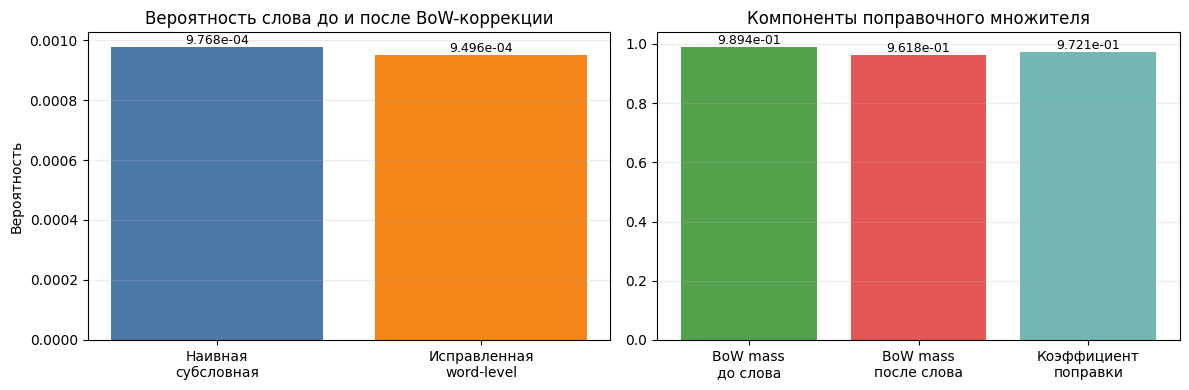


Модуль 2: метрики уверенности
{'ci_width_proxy': 0.5006198883056641, 'mean_entropy': 4.6111345291137695, 'mean_top1_margin': 0.1463215947151184, 'mean_hidden_iqr': 0.5418558716773987, 'mean_trajectory_energy': 50.91334533691406}

Интерпретация модуля 2
----------------------
Зачем проводился эксперимент: этот блок проверяет, можно ли получить полезный сигнал уверенности без семплера.
Мы специально не используем temperature/top-k/top-p, потому что случайный выбор токена меняет следующий
контекст и смешивает неопределенность модели с шумом декодирования. Вместо этого смотрим на логиты и hidden
states одного детерминированного forward pass. Средний ci_width_proxy = 0.5006: средняя структурная ширина:
есть заметная неопределенность, но без явного провала. Средняя энтропия = 4.6111, средний top-1 margin =
0.1463, Hidden IQR = 0.5419, энергия траектории = 50.9133. Как читать график: если красная линия CI width
proxy растет на отдельных токенах, эти позиции дают больший вклад в структурную н

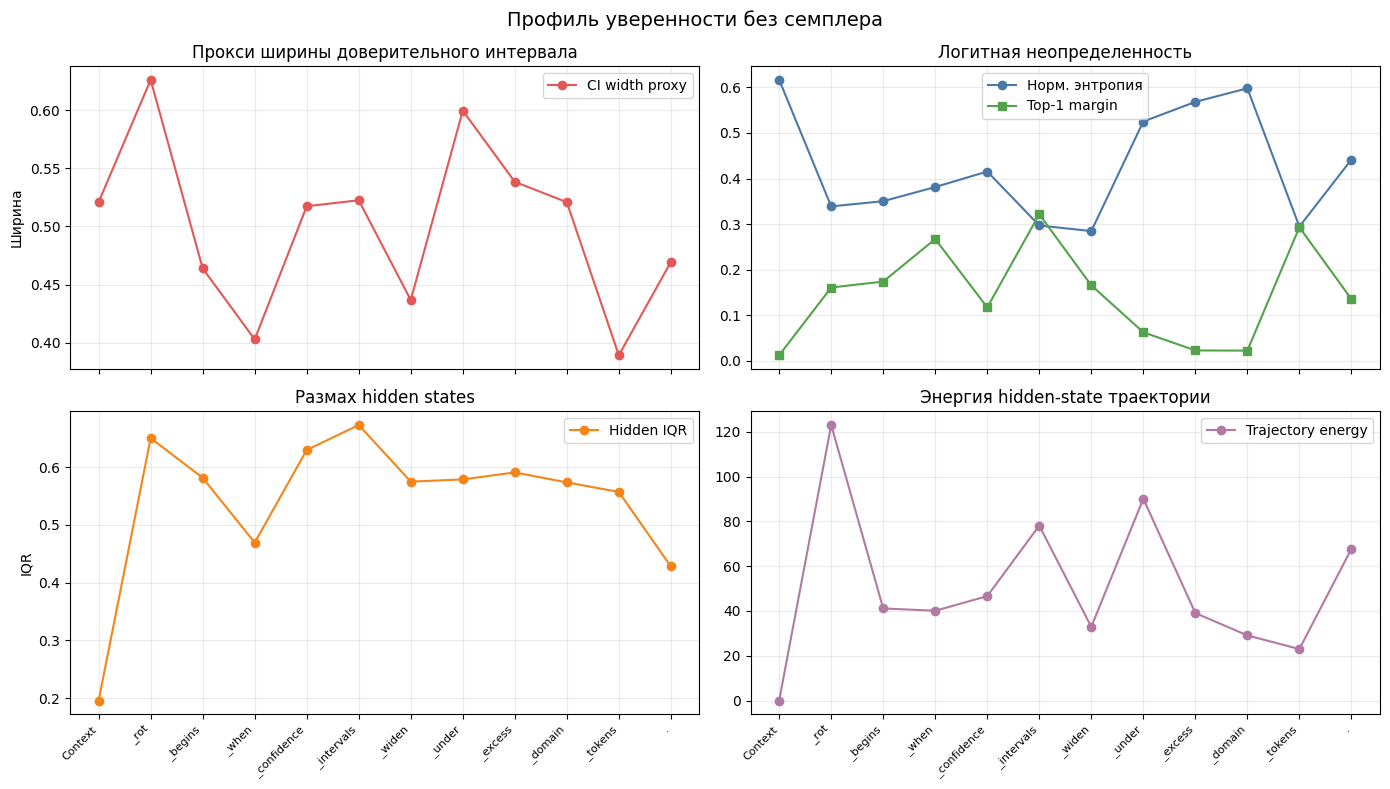


Модуль 3: детали MECW
{'breached': True, 'breach_index': 72, 'max_variance': 0.0035939091396633986, 'epsilon': 1e-10}

Интерпретация модуля 3
----------------------
Зачем проводился эксперимент: этот блок имитирует рост prompt/context и проверяет, в какой момент структурная
неопределенность перестает быть стабильной. Это практический аналог идеи MECW: нам важен не паспортный размер
окна модели, а длина, на которой добавление контекста еще не разрушает надежность вывода. В этом запуске MECW
нарушен на длине около 72 токенов. Максимальная наблюдаемая дисперсия ширины = 3.594e-03, порог epsilon =
1.000e-10. Как читать график: слева видно, как меняется ширина proxy-интервала при росте контекста; справа
видно, когда дисперсия пересекает красный порог. Практический вывод: после такой точки контекст лучше сжимать,
резюмировать или выносить в L2-буфер, а не продолжать наращивать активное окно.


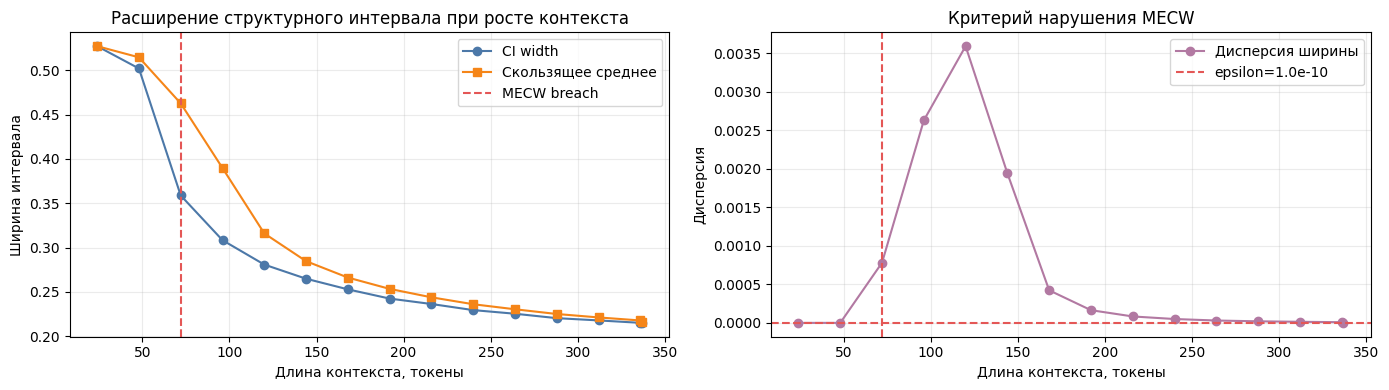


Модуль 4: n-граммный пайплайн и локоть
{'unique_ngrams': 43, 'perplexities': [7339.716813101718, 7326.395361425763, 3038.4475663630187, 1803.936299357104, 1803.936299357104], 'elbow': {'elbow_index': 3, 'elbow_length': 8, 'elbow_perplexity': 1803.936299357104, 'curvature': [6.176592166785016, 0.6292890681243122, 0.19934973966590167, 3.039658955060824, 1.7840465520613624]}}

Интерпретация модуля 4
----------------------
Зачем проводился эксперимент: этот блок проверяет идею доменного насыщения. Мы постепенно добавляем n-граммные
куски доменного текста и смотрим, продолжает ли модель получать пользу от нового контекста. Если перплексия
сначала резко меняется, а потом выходит на плато, значит основная статистическая структура домена уже усвоена
данным контекстом. Локоть найден при 8 n-граммных чанках. Перплексия на первой точке: 7339.717; на последней
точке: 1803.936; суммарное изменение: 5535.781. Как читать график: слева находится сама кривая perplexity,
справа — кривизна, по максимуму

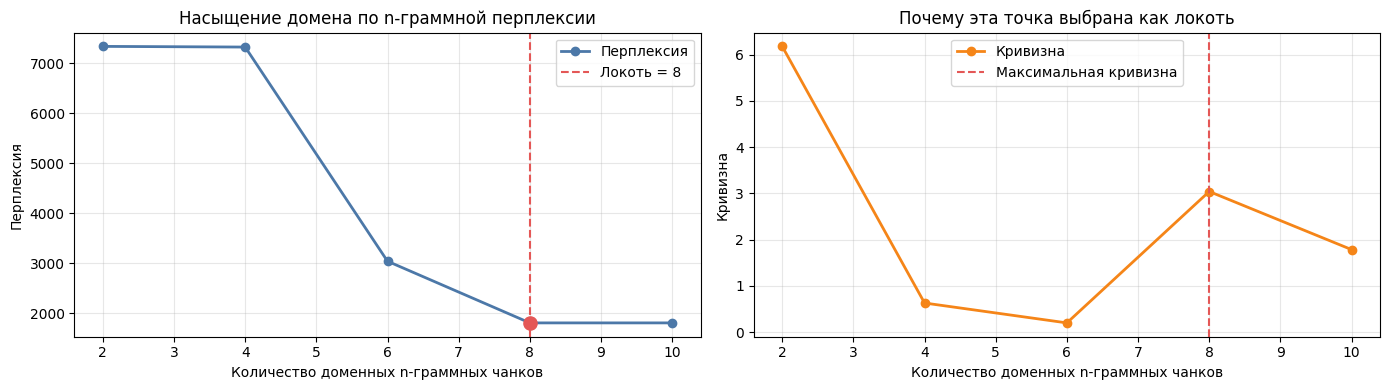


Модуль 4.1: подбор размера n-граммы
 n | unique | elbow_chunks | elbow_ppl | post_instab | score | valid
---|--------|--------------|-----------|-------------|-------|------
 1 |     44 |            8 | 278700.45 |      0.0305 | 0.769 |  True
 2 |     44 |            6 |  23676.69 |      0.0362 | 0.538 |  True
 3 |     43 |            8 |   3723.19 |      0.0000 | 0.141 |  True
 4 |     42 |            6 |   1109.62 |      0.0000 | 0.012 |  True
 5 |     41 |            6 |    991.83 |      0.0000 | 0.000 |  True
 6 |     40 |            6 |   1153.15 |      0.0000 | 0.016 |  True
 7 |     39 |            6 |   3423.27 |      0.0000 | 0.132 |  True
 8 |     38 |            4 |   3563.60 |      0.0000 | 0.136 |  True
 9 |     37 |            4 |   3912.90 |      0.0000 | 0.146 |  True
10 |     36 |            4 |   7624.24 |      0.0000 | 0.217 |  True

Интерпретация модуля 4.1
------------------------
Зачем проводился эксперимент: раньше n было зафиксировано как 3, поэтому мы проверял

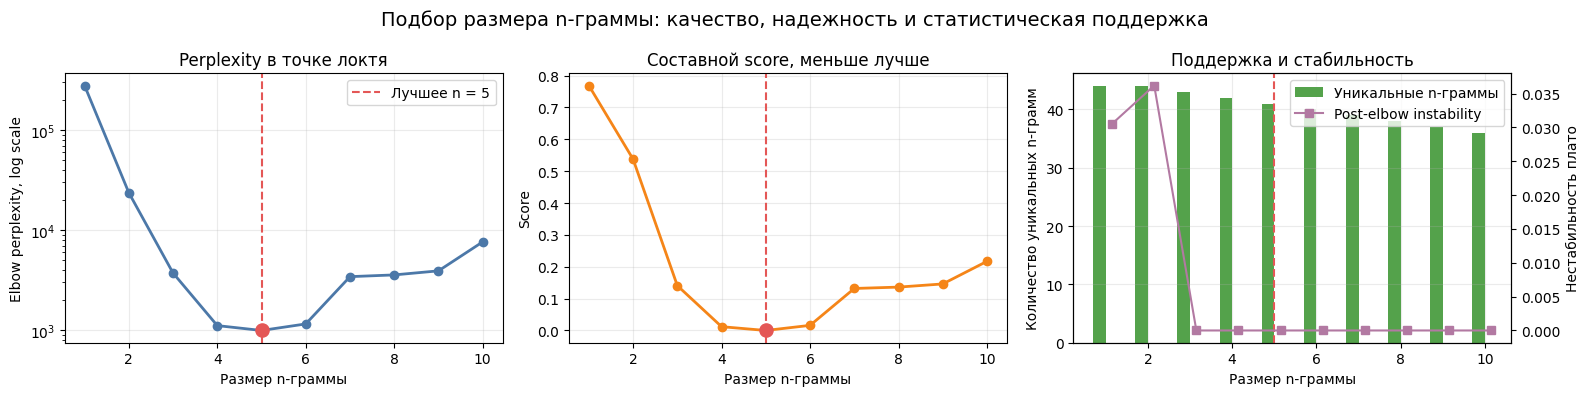


Модуль 6: результат сброса AgentContextManager
{'flushed': True, 'hypothesis_path': 'D:\\HANDMADE_LLM\\REPO\\qwen\\research\\hypothesis.md'}

Интерпретация модуля 6
----------------------
Зачем проводился эксперимент: этот блок показывает, что делать после обнаружения нарушения MECW. Вместо того
чтобы продолжать работу в перегруженном активном окне, агент выносит сжатое состояние в L2-буфер
`research/hypothesis.md` и очищает текущий контекст. В этом запуске контекст был сброшен и вынесен во внешний
L2-буфер. До сброса в активном окне было 337 токенов. Это соответствует SATLUTION/Kairos-паттерну: не
продолжать генерацию в деградировавшем окне, а сохранить сжатую гипотезу и начать следующий шаг с чистого
контекста.


In [10]:
def main():
    tokenizer, model = load_causal_lm("gpt2", device=DEVICE)

    # Демонстрация модуля 1: исправленная вероятность одного BoW-слова.
    context_text = "The deterministic language model estimates"
    target_word = " uncertainty"
    aligned_logits, target_ids = get_aligned_logits_for_word(model, tokenizer, context_text, target_word, device=DEVICE)
    corrected = compute_corrected_word_probability(aligned_logits, target_ids, tokenizer)
    corrected_p = corrected["corrected_probability"].reshape(-1)[0]
    assert torch.isfinite(corrected_p), "исправленная вероятность должна быть конечной"
    assert corrected_p.item() >= 0.0, "исправленная вероятность должна быть неотрицательной"
    assert int(corrected["bow_token_count"]) > 0, "BoW-маска должна содержать GPT-style BoW-токены"

    print("Модуль 1: исправленная вероятность слова")
    print({k: (float(v.reshape(-1)[0].detach().cpu()) if torch.is_tensor(v) and v.numel() else v) for k, v in corrected.items() if k != "subword_probabilities"})
    print_interpretation("Интерпретация модуля 1", interpret_probability_correction(corrected))
    plot_probability_correction(corrected)

    # Демонстрация модуля 2: структурные метрики уверенности.
    sample_text = "Context rot begins when confidence intervals widen under excess domain tokens."
    input_ids = tokenizer(sample_text, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, output_hidden_states=True)
    confidence = extract_confidence_metrics(outputs.logits, outputs.hidden_states)
    for key in ["ci_width_proxy", "mean_entropy", "mean_top1_margin", "mean_hidden_iqr", "mean_trajectory_energy"]:
        assert math.isfinite(float(confidence[key])), f"{key} должен быть конечным"
    print("\nМодуль 2: метрики уверенности")
    print({key: confidence[key] for key in ["ci_width_proxy", "mean_entropy", "mean_top1_margin", "mean_hidden_iqr", "mean_trajectory_energy"]})
    print_interpretation("Интерпретация модуля 2", interpret_confidence_metrics(confidence))
    plot_confidence_profile(confidence, tokenizer=tokenizer, input_ids=input_ids[0])

    # Демонстрация модуля 3: обнаружение MECW на расширяющемся синтетическом контексте.
    long_context = " ".join([
        "deterministic logits hidden states structural confidence ngram perplexity elbow saturation",
        "agent memory context rot mecw satlution hypothesis buffer compile test analyze evolve",
        "domain adaptation corrected word probability bow tokenizer marginalization surprisal",
    ] * 8)
    context_tokens = tokenizer(long_context, add_special_tokens=False).input_ids
    mecw = detect_mecw(context_tokens, window_step=24, model=model, tokenizer=tokenizer, epsilon=1e-10, min_windows=3, device=DEVICE, return_details=True)
    assert isinstance(mecw["breached"], bool), "флаг нарушения MECW должен быть boolean"
    print("\nМодуль 3: детали MECW")
    print({k: mecw[k] for k in ["breached", "breach_index", "max_variance", "epsilon"]})
    print_interpretation("Интерпретация модуля 3", interpret_mecw(mecw))
    plot_mecw_diagnostics(mecw)

    # Демонстрация модуля 4: доменные n-граммы, кривая исправленной перплексии и график локтя.
    domain_strings = [
        "Corrected word probability fixes BoW tokenizer marginalization and stabilizes surprisal.",
        "Structural confidence uses hidden-state trajectories, activation IQR, and logit entropy.",
        "MECW detection monitors widening intervals as context noise accumulates.",
        "SATLUTION stores compressed hypotheses in an L2 markdown buffer before resetting context.",
        "N-gram perplexity falls quickly, then reaches an elbow when domain structure saturates.",
    ]
    pipeline = build_ngram_domain_pipeline(domain_strings, n=3)
    max_len = min(10, len(pipeline["ngram_texts"]))
    lengths = list(range(2, max_len + 1, 2)) or [1]
    perplexity_result = calculate_context_perplexities(
        pipeline["ngram_texts"],
        model=model,
        tokenizer=tokenizer,
        lengths=lengths,
        device=DEVICE,
        use_corrected_words=True,
        max_words_per_eval=24,
    )
    elbow = find_elbow_point(perplexity_result["perplexities"], perplexity_result["lengths"])
    print("\nМодуль 4: n-граммный пайплайн и локоть")
    print({"unique_ngrams": len(pipeline["unique_ngrams"]), "perplexities": perplexity_result["perplexities"], "elbow": elbow})
    print_interpretation("Интерпретация модуля 4", interpret_elbow(perplexity_result, elbow))
    plot_perplexity_elbow(perplexity_result, elbow)

    # Демонстрация модуля 4.1: перебор размера n-граммы.
    ngram_sweep = sweep_best_ngram_size(
        domain_strings,
        model=model,
        tokenizer=tokenizer,
        n_values=range(1, 11),
        max_chunks_per_n=10,
        min_unique_ngrams=6,
        device=DEVICE,
        use_corrected_words=True,
        max_words_per_eval=16,
    )
    print()
    print("Модуль 4.1: подбор размера n-граммы")
    print(format_ngram_sweep_table(ngram_sweep))
    print_interpretation("Интерпретация модуля 4.1", interpret_ngram_sweep(ngram_sweep))
    plot_ngram_size_sweep(ngram_sweep)

    # Демонстрация модуля 6: сброс L2-контекста SATLUTION/Kairos.
    manager = AgentContextManager(model=model, tokenizer=tokenizer, window_step=24, epsilon=1e-10, device=DEVICE)
    manager.add_text(long_context)
    flush_result = manager.monitor_and_flush_if_needed()
    print("\nМодуль 6: результат сброса AgentContextManager")
    print({"flushed": flush_result.get("flushed"), "hypothesis_path": str(manager.hypothesis_path)})
    print_interpretation("Интерпретация модуля 6", interpret_agent_flush(flush_result))

    return {
        "corrected_probability": float(corrected_p.detach().cpu()),
        "confidence": {key: confidence[key] for key in ["ci_width_proxy", "mean_entropy", "mean_top1_margin"]},
        "mecw": mecw,
        "perplexity": perplexity_result,
        "elbow": elbow,
        "ngram_sweep": ngram_sweep,
        "flush_result": flush_result,
    }

if __name__ == "__main__":
    results = main()
